# 03 · Run the active-learning mode-shape loop ON THE INSTRUMENT

Drives an Asylum/Cypher system through Igor Pro to reconstruct the contact-resonance
mode shape from the **minimum number of laser positions**, choosing each position by
active learning and stopping when the displacement null spot (D-NS) is pinned.

**Windows / Igor only.** Requires `win32com` and `igor2`.

### Coordinates — read this once
`x = 0` is the **clamped base** and x increases toward the **free end**. The whole
package assumes this (`VirtualInstrument.measure_at`, and
`lowrank._signed_zero_crossing`, which resolves the null to the largest x as "nearest
the free end"), so do not flip it. Instead say where the laser is *parked* with
`START_AT`, and set `x_grid` to the part of the beam you can actually reach.

A D-NS of 212.3 µm on a 220 µm probe means 7.7 µm in from the free end —
`inst.um_from_free_end()` does the conversion, and the CSV log records both.

### Before you run — set up in Igor (once)
1. Approach and find the contact resonance at your chosen load.
2. **Set a FIXED tune range** bracketing **one** eigenmode's resonance *and* its
   antiresonance. No resonance tracking / auto-recenter — every position must be tuned
   over the *same* window.
3. **Check the resolution.** You need ≥6 points across the resonance FWHM. Igor's step
   is span/points, so 330–470 kHz at 992 points = 141 Hz ≈ 11 points across a 1.6 kHz
   FWHM. A 25 kHz–1.8 MHz span at 1984 points is 882 Hz ≈ 2 points — far too coarse.
   Also make the per-point dwell comfortably longer than the ring-down time
   `Q / (π f₀)` (≈ 0.2 ms at Q 240 / 390 kHz) or the peak comes out skewed.
4. **Park the detection laser where `START_AT` says**, and run the `preview_moves()`
   cell below to confirm the moves go *into* the cantilever before you engage.
5. Make sure the save folder exists and the base filename is set.

## 1 · Imports and connect to Igor

In [26]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import win32com.client
from activemodemap.asylum import AFMLaserSweepAutomation, AsylumInstrument
from activemodemap import (LowRankModeMap, plot_state, dns_branch,
                           LiveModeMapPlot, dense_reference_sweep, compare_to_dense,
                           dense_grid, PositionScale, fit_position_scale,
                           fit_position_scale_optical, peak_in_band)

# For a smoother live plot use the widget backend (pip install ipympl);
# the default inline backend works too, it just repaints the whole cell.
# %matplotlib widget

igor = win32com.client.Dispatch('IgorPro.Application')
print('Connected to Igor Pro')

Connected to Igor Pro


## 2 · Experiment parameters — edit these

In [27]:
# --- file locations (same convention as the dense-sweep notebook) ---
file_loc      = r'D:\User Data\Liam\ActiveModeMap\SCM_PIT\Dense_Grid_B'   # must exist
base_filename = 'AMap'
log_filename  = os.path.join(file_loc, 'AMap_log')

# --- contact / drive ---
load_nN   = 1500      # applied load (nN)
dc_bias_V = 0.0       # DC bias on Output.A (single-domain D-NS map)

# --- frequency handling ---------------------------------------------------
# The map is ALWAYS reconstructed over the whole tune window, at every position:
# the low-rank fit is an independent least-squares solve at each frequency, so
# covering the full spectrum costs nothing and nothing is discarded. Both
# resonances, the antiresonance branch, and the off-resonance background all come
# out of the same fit.
#
# DNS_BAND_HZ only tells the null-spot estimator where to look, because its
# antiresonance search window is a fraction of the span it is handed -- give it
# 1.7 MHz and that search is meaningless. Set it around ONE mode; reprocess the
# saved tunes afterwards for the other one.
DNS_BAND_HZ    = (270e3, 410e3)     # locate the null using the ~387 kHz mode
tune_center_Hz = 300.5e3            # logging only

# --- geometry and the reachable span --------------------------------------
# x = 0 is the CLAMPED BASE; x increases toward the FREE END.
PROBE_L_UM = 225.0    # full cantilever length
START_AT   = 'free_end'   # where the laser is parked: 'free_end' or 'base'

# The span you can actually reach. On a stiff probe the base end is often
# inaccessible; just map the part you can reach and set x_grid to match — the
# Chebyshev basis is fitted over x_grid's own range, so restricting it keeps the
# reconstruction an interpolation. Do NOT set x_grid wider than what you measure:
# the low-rank model cannot extrapolate (see docs/SPAN_AND_SAMPLING.md).
REACH_UM   = 120.0    # how far in from the free end you can get
step_um    =0.5
x_grid     = np.arange(PROBE_L_UM - REACH_UM, PROBE_L_UM + 1e-6, step_um)   # 100..220

# Which DoLDMove sign moves the spot toward the free end (+1 on this Cypher).
# Verify with preview_moves() below before engaging.
HW_SIGN_TOWARD_FREE_END = +1

# --- active-learning settings ---
# RANK is the knob that sets how few positions you need: the fit needs at least
# RANK positions to be determined at all, RANK+1 for any residual, and RANK+2 for
# a residual with 2 dof (the smallest honest default). Simulation and the Demo1
# data both put rank 4-5 at sub-micron D-NS accuracy; rank 3 is systematically
# ~3 um out while looking MORE stable, and rank 6+ overfits. Rank 4 makes 6
# positions a realistic floor -- see docs/RANK_AND_POSITIONS.md.
RANK          = 4       # spatial basis dimension (4 or 5; NOT 3)
MAX_POSITIONS = 20      # hard cap on positions actually measured
MIN_POSITIONS = 6       # = RANK + 2; fewer leaves too little residual for a real CI
DNS_CI_TOL_UM = 0.5    # stop once the D-NS 95% CI is below this
RECALIBRATE_EACH = True # AutoWedge + InvOLS at every position

os.makedirs(file_loc, exist_ok=True)
print(f'probe {PROBE_L_UM:.0f} um; mapping x = {x_grid[0]:.0f}-{x_grid[-1]:.0f} um '
      f'(0 = base), i.e. the {REACH_UM:.0f} um nearest the free end')

probe 225 um; mapping x = 105-225 um (0 = base), i.e. the 120 um nearest the free end


## 3 · Build the automation, the instrument adapter, and the loop manager

In [28]:
automation = AFMLaserSweepAutomation(igor, file_loc, base_filename, log_filename)
automation.eigenmode_center_freq = tune_center_Hz
automation.autowedge_pause = 15.0
automation.invols_bounds = (3e-8, 15e-7)
automation.resonance_band_Hz = DNS_BAND_HZ    # for the logged f_res / Q only

# analysis_band_Hz is left None on purpose: measure_at hands the FULL spectrum to
# the loop, and the band is applied downstream by LowRankModeMap(dns_band_Hz=...)
inst = AsylumInstrument(automation, load_nN=load_nN, dc_bias_V=dc_bias_V,
                        recalibrate_each=RECALIBRATE_EACH,
                        analysis_band_Hz=None,
                        start_at=START_AT, span_um=PROBE_L_UM,
                        x_limits_um=(x_grid[0], x_grid[-1]),
                        hw_sign_toward_free_end=HW_SIGN_TOWARD_FREE_END)

mm = LowRankModeMap(x_grid, freq_grid=None, rank=RANK,
                    seeds_um=[x_grid[0], x_grid[len(x_grid)//2], x_grid[-1]],
                    min_positions=MIN_POSITIONS, dns_ci_tol_um=DNS_CI_TOL_UM,
                    start_near_um=(x_grid[-1] if START_AT == 'free_end' else x_grid[0]),
                    dns_band_Hz=DNS_BAND_HZ, stable_over=3)

# ---- CHECK THE DIRECTION BEFORE ENGAGING -------------------------------------
# Walking inward from the free end, every move should read "toward base".
# If they read "toward free end", flip HW_SIGN_TOWARD_FREE_END and re-run.
inst.preview_moves([mm.x_grid[i] for i in mm._order[:MAX_POSITIONS]])

start: x = 225.0 um (free end, 0.0 um from the free end)
  x = 0 is the clamped base; hw_sign_toward_free_end = +1
  x =   225.0 um   DoLDMove(    +0.0, 0)   no move
  x =   165.0 um   DoLDMove(   -60.0, 0)   toward base
  x =   105.0 um   DoLDMove(   -60.0, 0)   toward base
  x =   130.5 um   DoLDMove(   +25.5, 0)   toward free end
  x =   195.5 um   DoLDMove(   +65.0, 0)   toward free end
  x =   224.5 um   DoLDMove(   +29.0, 0)   toward free end
  x =   105.5 um   DoLDMove(  -119.0, 0)   toward base
  x =   136.0 um   DoLDMove(   +30.5, 0)   toward free end
  x =   193.5 um   DoLDMove(   +57.5, 0)   toward free end
  x =   224.0 um   DoLDMove(   +30.5, 0)   toward free end
  x =   106.0 um   DoLDMove(  -118.0, 0)   toward base
  x =   137.5 um   DoLDMove(   +31.5, 0)   toward free end
  x =   192.5 um   DoLDMove(   +55.0, 0)   toward free end
  x =   138.0 um   DoLDMove(   -54.5, 0)   toward base
  x =   223.5 um   DoLDMove(   +85.5, 0)   toward free end
  x =   106.5 um   DoLDMove(

## 4 · Run the active-learning loop — live

Each iteration: pick the next position, drive the instrument (withdraw → move laser →
optical image → AutoWedge+InvOLS → engage → tune → read the complex spectrum →
withdraw), update the reconstruction, and redraw.

`LiveModeMapPlot` reuses a single figure and replaces the cell output each time, so you
watch one panel evolve instead of accumulating plots. The four panels are the
reconstructed map over the **whole** tune window, its uncertainty, the measured spectra
against the fit, and the D-NS convergence trace. A redraw is ~0.2 s against ~60 s per
position, so the display costs nothing.

Interrupt the cell at any time; whatever has been measured is retained in `mm` and
`inst.records`.

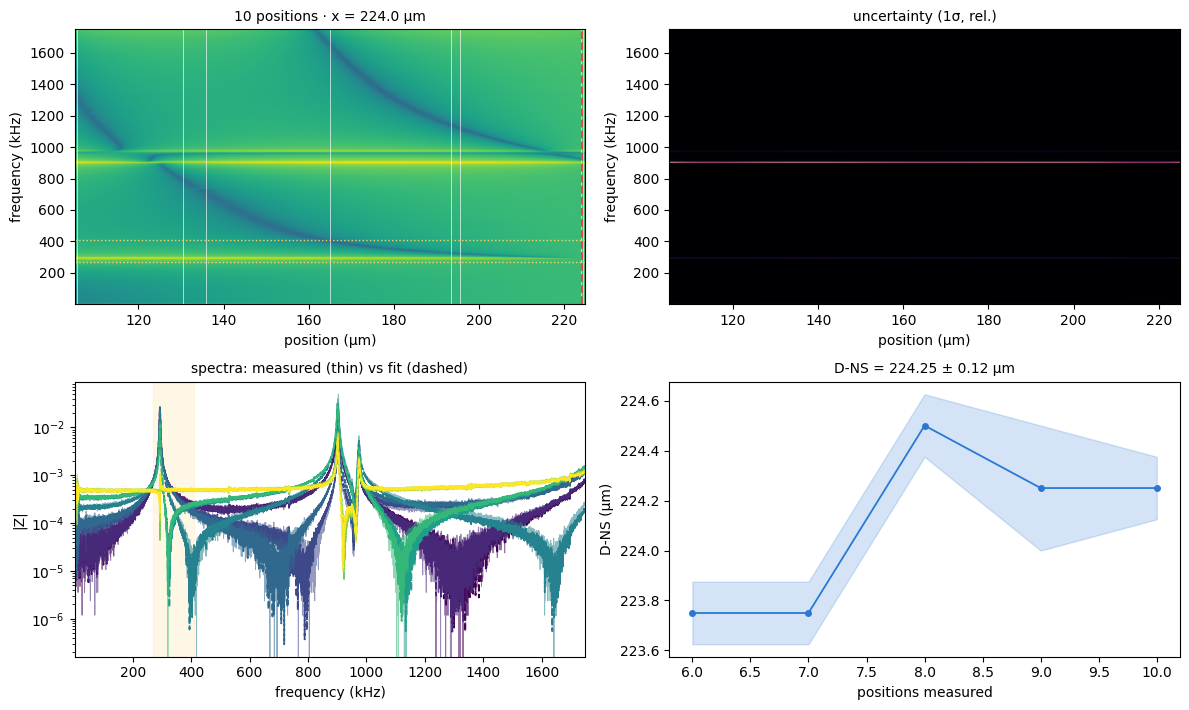

n=10  x= 224.0 µm   D-NS 224.25 ± 0.12 µm (0.75 µm from the free end)   crossings [224.2]

Converged — CI below tolerance AND the estimate has stopped moving.

Loop done. Positions measured: 10


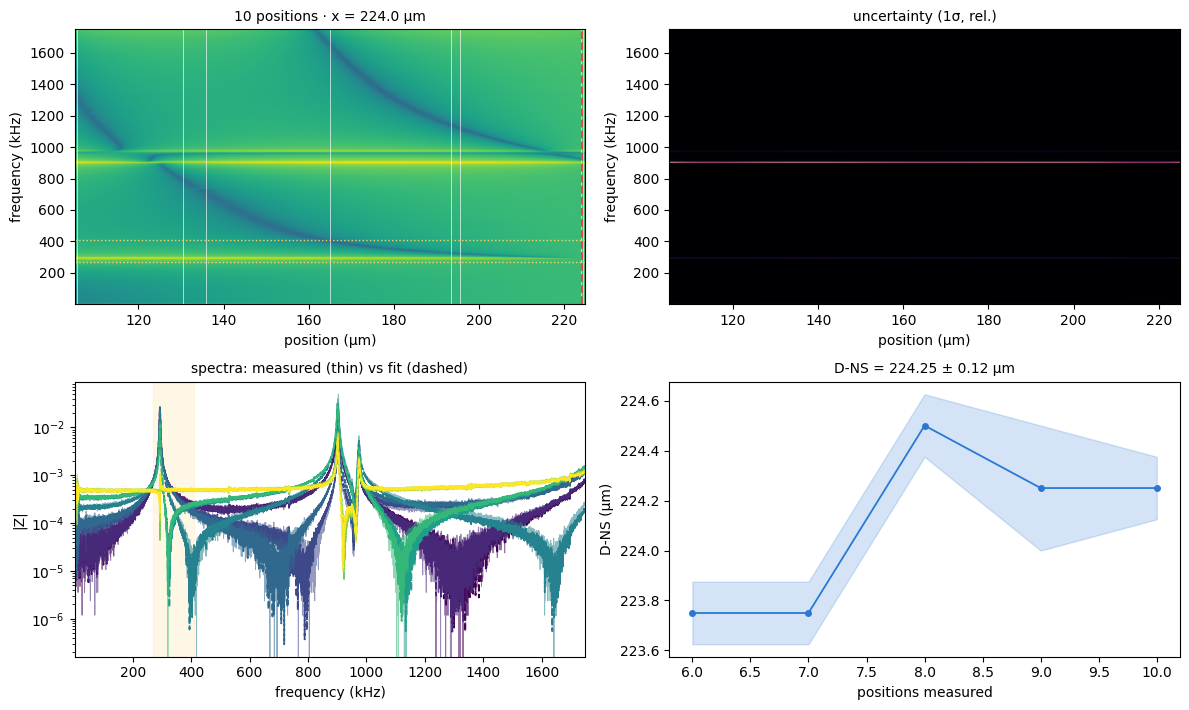

In [29]:
live = LiveModeMapPlot()
rec = None
for step in range(MAX_POSITIONS):
    x = mm.next_position()
    freq, Z, meta = inst.measure_at(x)

    # --- sanity check the spectrum BEFORE it enters the reconstruction ---
    if mm.n == 0:
        df = float(np.median(np.diff(freq)))
        print(f"tune window: {freq[0]/1e3:.1f}-{freq[-1]/1e3:.1f} kHz, "
              f"{freq.size} points, {df:.0f} Hz step")
        ipk = int(np.argmax(np.abs(Z)))
        print(f"strongest response: {freq[ipk]/1e3:.2f} kHz")
        assert freq.size >= 32, 'truncated spectrum — do not proceed'
        lo, hi = DNS_BAND_HZ
        assert (freq >= lo).any() and (freq <= hi).any(), \
            'DNS_BAND_HZ does not overlap the tune window'

    mm.add_measurement(x, freq, Z)
    if mm.n >= mm.min_positions:
        rec = mm.reconstruct(nboot=150)
        live.update(mm, rec, title=f'{mm.n} positions · x = {x:.1f} µm')
        xc = rec['crossings']
        print(f"n={mm.n:2d}  x={x:6.1f} µm   "
              f"D-NS {rec['dns']:.2f} ± {rec['dns_ci']/2:.2f} µm "
              f"({inst.um_from_free_end(rec['dns']):.2f} µm from the free end)   "
              f"crossings {np.round(xc, 1)}")
        if mm.converged():
            print('\nConverged — CI below tolerance AND the estimate has stopped moving.')
            break
    else:
        print(f"n={mm.n:2d}  x={x:6.1f} µm   (need {mm.min_positions} before fitting)")

inst.close()   # withdraw + zero DC bias
print('\nLoop done. Positions measured:', mm.n)

## 5 · Final reconstruction and save

saved ActiveModeMap_result.png / .npz  and ActiveModeMap_log.csv
reconstructed map: 241 positions x 16000 frequencies, 0.1-1750.0 kHz
D-NS = 224.25 ± 0.12 µm  = 0.75 µm from the free end   (from 10 positions)

  D-NS vs rank (10 positions):
    rank 3:   223.75 um
    rank 4:   224.25 um
    rank 5:   224.08 um
  median 224.08 um, spread across neighbouring ranks 0.50 um
  ^ use that spread, not the bootstrap CI, as the uncertainty you quote


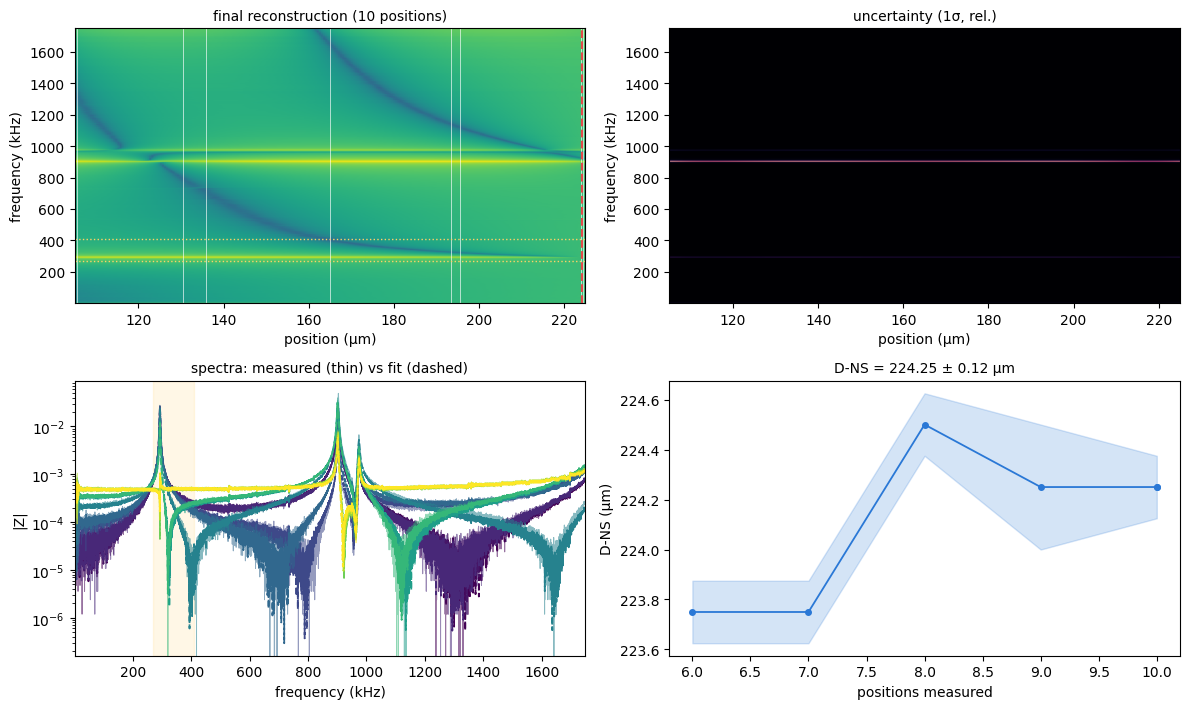

In [30]:
rec = mm.reconstruct(nboot=400)
ax = plot_state(mm, rec, title=f'final reconstruction ({mm.n} positions)')
fig = ax.ravel()[0].figure
fig.savefig(os.path.join(file_loc, 'ActiveModeMap_result.png'), dpi=150, bbox_inches='tight')

# save the FULL reconstructed spectrum at every grid position, the raw measured
# spectra, and the per-position log
sel = rec['sel_idx']
np.savez(os.path.join(file_loc, 'ActiveModeMap_result.npz'),
         x_grid=mm.x_grid, freq=mm.freq, Zrec=rec['Zrec'], std=rec['std'],
         measured_x=mm.x_grid[sel], measured_Z=rec['Zsel'],
         dns=rec['dns'], dns_ci=rec['dns_ci'], dns_samples=rec['dns_samples'],
         crossings=rec['crossings'], fa=rec['fa'], ires=rec['ires'],
         dns_band_Hz=np.asarray(DNS_BAND_HZ, float),
         probe_L_um=PROBE_L_UM, um_from_free_end=PROBE_L_UM - rec['dns'])
log_path = inst.save_log()
print(f"saved ActiveModeMap_result.png / .npz  and {os.path.basename(log_path)}")
print(f"reconstructed map: {rec['Zrec'].shape[0]} positions x {rec['Zrec'].shape[1]} "
      f"frequencies, {mm.freq[0]/1e3:.1f}-{mm.freq[-1]/1e3:.1f} kHz")
print(f"D-NS = {rec['dns']:.2f} ± {rec['dns_ci']/2:.2f} µm  "
      f"= {PROBE_L_UM - rec['dns']:.2f} µm from the free end   "
      f"(from {mm.n} positions)")
if len(rec['crossings']) > 1:
    print(f"branch crossings: {np.round(rec['crossings'], 1)} µm — more than one null")

# The bootstrap CI only propagates noise through a fit whose rank is assumed
# correct, so it is blind to the dominant error: the choice of rank. Re-fitting
# the same data at neighbouring ranks costs nothing and is far more honest.
print()
sens = mm.rank_sensitivity()

## 5b · Resuming after an interruption, or after updating the library

Two things make a naive "just re-run the cell" fail:

1. **Python caches modules.** Editing `activemodemap/*.py` on disk does nothing to a
   kernel that already imported it. Re-running a cell re-runs the *old* code.
2. **Restarting the kernel loses `inst`.** The laser position is tracked in software,
   so a restart throws away the only record of where the spot is — and a fresh
   instrument that assumes `start_at` will be wrong by however far the run wandered.

So prefer **path A**, which reloads the module without losing the instrument. Use
path B only if the kernel is already gone.

# ============================================================================
# PATH A — library updated, kernel still alive (PREFERRED)
# Reloads the module and rebinds the names. `inst` survives, so the tracked laser
# position is kept, and `mm` / `rec` are untouched. Then just re-run the cells you
# need. Costs no microscope time.
# ============================================================================
import importlib
import activemodemap.online, activemodemap.lowrank, activemodemap.asylum
for _m in (activemodemap.lowrank, activemodemap.online, activemodemap.asylum):
    importlib.reload(_m)
from activemodemap.online import (dense_reference_sweep, compare_to_dense,
                                  dense_grid, plot_state, LiveModeMapPlot,
                                  PositionScale, fit_position_scale,
                                  fit_position_scale_optical, peak_in_band)
from activemodemap.lowrank import dns_branch

print(f'reloaded. inst still tracks x = {inst.current_x:.1f} um; mm has {mm.n} positions')
print('note: mm and inst are still instances of the OLD classes, so their *methods*')
print('are the old ones. That is fine for re-running the dense sweep (a module-level')
print('function), but if a fix touched LowRankModeMap or AsylumInstrument behaviour')
print('you need path B.')

# ============================================================================
# PATH B — kernel was restarted. Rebuild without going back on the microscope.
# Run cells 1-3 first (imports, parameters, automation), then this INSTEAD of the
# acquisition loop. Skip it entirely if you used path A.
# ============================================================================
REBUILD_FROM_DISK = False        # set True to use this path

if REBUILD_FROM_DISK:
    # --- 1. where is the laser, really? -------------------------------------
    # Software tracking is gone. Take the last position printed before the
    # interruption, CONFIRM IT OPTICALLY, and put it here. Getting this wrong
    # offsets every later move.
    LASER_IS_AT_UM = 224.0       # <-- EDIT ME, then verify with the video panel

    inst = AsylumInstrument(automation, load_nN=load_nN, dc_bias_V=dc_bias_V,
                            recalibrate_each=RECALIBRATE_EACH,
                            analysis_band_Hz=None,
                            x_start_um=LASER_IS_AT_UM,      # overrides start_at
                            span_um=PROBE_L_UM,
                            x_limits_um=(x_grid[0], x_grid[-1]),
                            hw_sign_toward_free_end=HW_SIGN_TOWARD_FREE_END)
    print(f'instrument rebuilt, laser declared at x = {inst.current_x:.1f} um '
          f'({inst.um_from_free_end(inst.current_x):.1f} um from the free end)')

    # --- 2. rebuild the reconstruction from the saved result ----------------
    # ActiveModeMap_result.npz stores the measured spectra and their frequency
    # axis, so the active-learning result is recoverable exactly, with no
    # re-measuring. (scripts/reprocess_tune_folder.py does the same from the raw
    # Tune_*.txt files if the npz is missing.)
    _d = np.load(os.path.join(file_loc, 'ActiveModeMap_result.npz'))
    mm = LowRankModeMap(x_grid, freq_grid=None, rank=RANK,
                        seeds_um=[x_grid[0], x_grid[len(x_grid)//2], x_grid[-1]],
                        min_positions=MIN_POSITIONS, dns_ci_tol_um=DNS_CI_TOL_UM,
                        start_near_um=(x_grid[-1] if START_AT == 'free_end' else x_grid[0]),
                        dns_band_Hz=DNS_BAND_HZ, stable_over=3)
    for _x, _z in zip(_d['measured_x'], _d['measured_Z']):
        mm.add_measurement(float(_x), _d['freq'], _z)
    rec = mm.reconstruct(nboot=400)
    print(f'rebuilt mm from disk: {mm.n} positions, D-NS {rec["dns"]:.2f} um '
          f'(saved value was {float(_d["dns"]):.2f} um)')
    assert abs(rec['dns'] - float(_d['dns'])) < 0.5, 'rebuild disagrees with the saved result'
else:
    print('skipped (REBUILD_FROM_DISK is False)')

## 6 · Dense reference sweep — the ground truth

Measures **every** position on a uniform grid, with no reconstruction and no
low-rank assumption: this *is* the map, and it is what the sparse result should be
judged against.

**The laser is moved back to the free end first.** This matters more than it looks.
Position is tracked in software from relative `DoLDMove` calls, so an instrument
object only knows where the spot is if it did every move itself. The active-learning
loop leaves the laser at whichever position it measured last (mid-span), so building
a *new* `AsylumInstrument` with `start_at='free_end'` would simply assert
`current_x = 225` while the spot sat at, say, 138 µm — and every dense move would
inherit that 87 µm offset. Asking for 225 → 107 would really traverse 138 → 20 and
run the spot off the base onto the chip, with the travel guard none the wiser
because it checks the *believed* position.

So the cell below reuses the same `inst` object, re-applies the DC bias that
`close()` zeroed, and calls `inst.move_to(x_park)` — one explicit, tracked,
limit-checked move, with an optical image so you can confirm the spot before
committing to a two-hour sweep.

The grid then starts at that parked position and walks inward at a constant pitch:
no wasted traverse, no direction reversals to accumulate backlash, and the sweep
progresses steadily across the beam because `dense_reference_sweep` measures in the
order given.

Budget roughly a minute per position — 1 µm over 118 µm is ~119 points, ~2 hours.
Interrupting is safe: whatever was measured is returned.

In [31]:
DENSE_STEP_UM = 0.5     # uniform pitch; 1 um over a 118 um span is ~119 points

x_park = x_grid[-1] if START_AT == 'free_end' else x_grid[0]
x_far  = x_grid[0]  if START_AT == 'free_end' else x_grid[-1]

# Reuse the instrument from the loop: it is the only object that knows where the
# spot actually is. A fresh one would assume, and be wrong by however far the loop
# wandered. (If the kernel was restarted, see the note in the markdown above and
# re-sync deliberately with inst.set_position(<verified x>, confirm=True).)
print(f'laser is tracked at x = {inst.current_x:.1f} um after the loop')
inst.apply_dc_bias()                       # close() zeroed it
inst.move_to(x_park, warn_above_um=20)     # explicit, limit-checked, with an image

x_dense = dense_grid(x_park, x_far, DENSE_STEP_UM)
print(f'\n{x_dense.size} positions at {DENSE_STEP_UM:g} um pitch, '
      f'{x_dense[0]:.1f} -> {x_dense[-1]:.1f} um '
      f'({"inward from the free end" if START_AT == "free_end" else "outward from the base"})')
print(f'estimated time: ~{x_dense.size} min. Raise DENSE_STEP_UM to cut it down.')

# Mark the record boundary BEFORE the dense sweep starts. inst.records accumulates
# across both passes, and section 7 needs them separated to fit the position-scale
# correction from InvOLS. Recovering the split afterwards by matching positions is
# ambiguous the moment a position is revisited or retried.
n_rec_sparse = len(inst.records)

x_d, F_d, Z_d = dense_reference_sweep(inst, x_dense)   # measured in this order
inst.close()

records_sparse = inst.records[:n_rec_sparse]
records_dense  = inst.records[n_rec_sparse:]
print(f'records: {len(records_sparse)} from the AL loop, {len(records_dense)} from the dense sweep')

np.savez(os.path.join(file_loc, 'DenseReference.npz'), x_um=x_d, freq_Hz=F_d, Z=Z_d,
         step_um=DENSE_STEP_UM, probe_L_um=PROBE_L_UM,
         n_rec_sparse=n_rec_sparse)
inst.save_log(os.path.join(file_loc, 'DenseReference_log.csv'))
print(f'\nsaved DenseReference.npz — {x_d.size} positions x {F_d.size} frequencies')

laser is tracked at x = 224.0 um after the loop
  laser moved to x = 225.0 um (0.0 um from the free end)  [DoLDMove(+1.0)]
  optical image captured — check the spot is on the cantilever before continuing

241 positions at 0.5 um pitch, 225.0 -> 105.0 um (inward from the free end)
estimated time: ~241 min. Raise DENSE_STEP_UM to cut it down.
  [1/241] x =   225.0 um   16000 pts 0.1-1750.0 kHz   elapsed 1.1 min, ~264 min left
  [2/241] x =   224.5 um   16000 pts 0.1-1750.0 kHz   elapsed 2.2 min, ~266 min left
  [3/241] x =   224.0 um   16000 pts 0.1-1750.0 kHz   elapsed 3.4 min, ~266 min left
  [4/241] x =   223.5 um   16000 pts 0.1-1750.0 kHz   elapsed 4.5 min, ~266 min left
  [5/241] x =   223.0 um   16000 pts 0.1-1750.0 kHz   elapsed 5.6 min, ~265 min left
  [6/241] x =   222.5 um   16000 pts 0.1-1750.0 kHz   elapsed 6.8 min, ~265 min left
  [7/241] x =   222.0 um   16000 pts 0.1-1750.0 kHz   elapsed 7.9 min, ~263 min left
  [8/241] x =   221.5 um   16000 pts 0.1-1750.0 kHz   elapsed 

## 7 · Sparse vs dense — did the active loop get it right?

**The two passes do not share a position axis, and the comparison has to fix that
before it means anything.** `DoLDMove` under-delivers on small steps, so a dense
sweep built from hundreds of chained 0.5 µm moves travels less than its axis says,
while the AL loop's handful of large jumps arrive essentially where they were asked
to. On Demo6Fullgrid the dense pass covered only 85% of its commanded 140 µm, which
put its labelled x = 85 µm about 25 µm away from the loop's x = 85 µm — the two were
being compared at different places on the cantilever.

`fit_position_scale` recovers this from data the run already has. InvOLS is a steep
monotonic function of true spot position (~5x from free end to base) and is measured
at every position of both passes, so the scale factor that maps the dense pass's
InvOLS-vs-position curve onto the loop's *is* the travel shortfall. On Demo6 it
returns 0.847 with 0.65 µm residuals, against 0.851 measured independently from the
optical images — 0.5% agreement. The optical route is available as
`fit_position_scale_optical` if you want that second opinion (it needs the FAMap
`.tif` frames).

Everything positional is then computed on the corrected axis, because a D-NS read
off a 15%-compressed axis is wrong by 15% of its distance from the anchor. The
uncorrected numbers are printed alongside so you can see how big the repair was.
Dense positions whose corrected value falls outside the sparse grid are dropped
rather than extrapolated — on Demo6 the dense sweep's real coverage stopped around
110 µm, so "disagreement" below that was extrapolation.

The amplitude panel compares **peak-in-band**, not |Z| at one fixed frequency. The
contact resonance wandered 386.9–389.2 kHz across Demo6 while the linewidth was only
~1.3–2.8 kHz, so a fixed cut sampled a different part of every peak and turned f_res
jitter into fake amplitude structure — on its own that accounted for a 1.46x → 1.18x
slice of the apparent mismatch.

If you have independent grounds to believe the two passes really do share an axis,
say so explicitly with `position_scale=PositionScale.identity()`. The function
refuses to assume it.

  position scale from InvOLS: PositionScale(scale=0.8300, offset=+38.96um, source=invols, n=7, rms=0.77um)
    dense axis is compressed 17.0% — its span is really 99.6 um, not 120.0 um
    excluded [225.  105.  105.5] um (InvOLS outside the dense pass's range -> never actually covered by it)
  dropped 2 of 241 dense positions: corrected positions outside the sparse grid [105.0, 225.0] um. Comparing there would be extrapolation, not disagreement.

position scale : PositionScale(scale=0.8300, offset=+38.96um, source=invols, n=7, rms=0.77um)
dense  D-NS : 224.43 µm  (0.57 µm from the free end) from 239 positions
sparse D-NS : 224.25 µm  (0.75 µm from the free end) from 10 positions
difference  : -0.18 µm      speed-up: 23.9x fewer positions
  (uncorrected this would have read dense 223.47 µm, difference +0.78 µm — the size of the repair)
map error   : mean 30.1%, max 43.2% (per position, relative)
peak |Z| sparse/dense: median 0.991 over 270-410 kHz

saved SparseVsDense.png


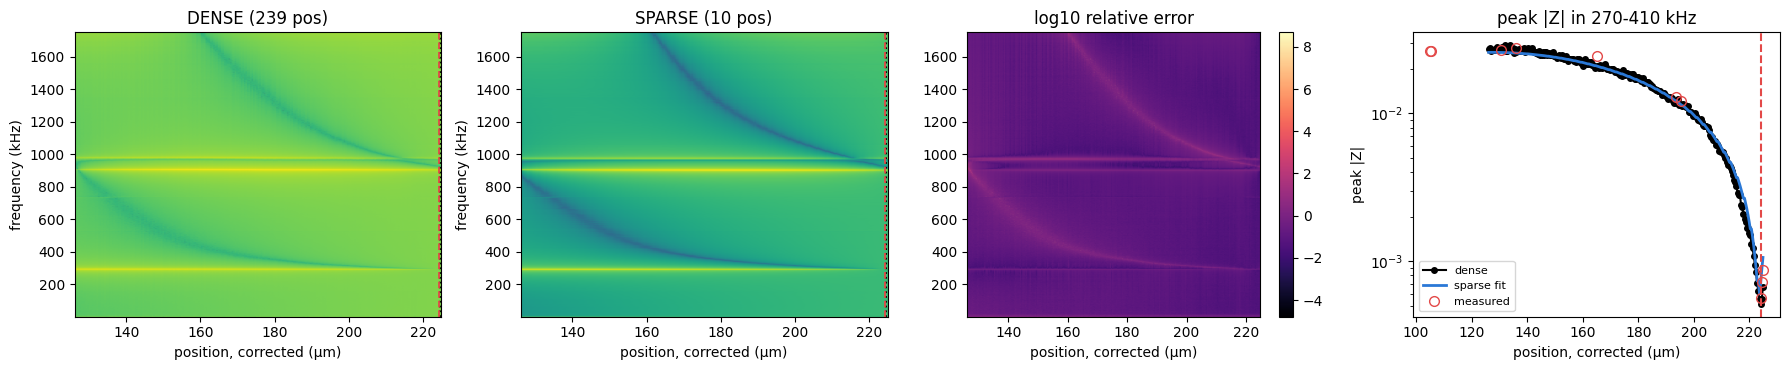

In [32]:
# --- 1. recover the dense pass's true position axis from its own InvOLS ------
# Falls back to identity ONLY if the records are missing (e.g. an old checkpoint),
# and says so loudly rather than quietly comparing mismatched axes.
try:
    pscale = fit_position_scale(records_sparse, records_dense)
except (NameError, ValueError) as e:
    print(f'!! could not fit the position scale ({e})')
    print('!! falling back to IDENTITY — positions are assumed shared, which for a '
          'dense sweep of small steps is probably WRONG. Treat D-NS with suspicion.')
    pscale = PositionScale.identity()

cmp = compare_to_dense(mm, rec, x_d, F_d, Z_d, dns_band_Hz=DNS_BAND_HZ,
                       position_scale=pscale)
x_dc = cmp['x_dense_corrected']

print(f"\nposition scale : {cmp['position_scale']}")
print(f"dense  D-NS : {cmp['dns_dense']:.2f} µm  "
      f"({inst.um_from_free_end(cmp['dns_dense']):.2f} µm from the free end) "
      f"from {cmp['n_dense']} positions")
print(f"sparse D-NS : {cmp['dns_sparse']:.2f} µm  "
      f"({inst.um_from_free_end(cmp['dns_sparse']):.2f} µm from the free end) "
      f"from {cmp['n_sparse']} positions")
print(f"difference  : {cmp['delta']:+.2f} µm      "
      f"speed-up: {cmp['n_dense']/cmp['n_sparse']:.1f}x fewer positions")
if not cmp['position_scale'].is_identity:
    print(f"  (uncorrected this would have read dense {cmp['dns_dense_raw']:.2f} µm, "
          f"difference {cmp['delta_raw']:+.2f} µm — the size of the repair)")
print(f"map error   : mean {100*cmp['rel_err_mean']:.1f}%, max {100*cmp['rel_err_max']:.1f}% "
      "(per position, relative)")
print(f"peak |Z| sparse/dense: median {cmp['peak_ratio_median']:.3f} "
      f"over {cmp['amp_band_Hz'][0]/1e3:.0f}-{cmp['amp_band_Hz'][1]/1e3:.0f} kHz")
if len(cmp['crossings_dense']) > 1:
    print(f"NOTE: dense map has {len(cmp['crossings_dense'])} branch crossings: "
          f"{np.round(cmp['crossings_dense'], 1)} µm — more than one null in the span.")

# --- 2. optional independent check from the optical frames -------------------
# Uncomment to cross-check the InvOLS scale against the saved FAMap images.
# import glob
# tifs = sorted(glob.glob(os.path.join(file_loc, 'FAMap*.tif')))
# print(fit_position_scale_optical(tifs[:len(records_sparse)],
#                                  [r['position_x_um'] for r in records_sparse]))

# --- 3. side by side, all on the corrected axis ------------------------------
fk = mm.freq / 1e3
Zs = rec['Zrec'][[int(np.argmin(np.abs(mm.x_grid - x))) for x in x_dc]]
ext = [x_dc[0], x_dc[-1], fk[0], fk[-1]]
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
for a, (M, t) in zip(ax[:2], [(cmp['Z_dense_on_grid'], f'DENSE ({cmp["n_dense"]} pos)'),
                              (Zs, f'SPARSE ({cmp["n_sparse"]} pos)')]):
    a.imshow(np.log10(np.abs(M).T + 1e-12), origin='lower', aspect='auto',
             extent=ext, cmap='viridis')
    a.axvline(cmp['dns_dense'], color='k', ls=':', lw=1.3)
    a.axvline(cmp['dns_sparse'], color='#e34948', ls='--', lw=1.3)
    a.set_title(t); a.set_xlabel('position, corrected (µm)'); a.set_ylabel('frequency (kHz)')
im = ax[2].imshow(np.log10(np.abs(Zs - cmp['Z_dense_on_grid']).T
                           / (np.abs(cmp['Z_dense_on_grid']).T + 1e-12) + 1e-6),
                  origin='lower', aspect='auto', extent=ext, cmap='magma')
ax[2].set_title('log10 relative error'); ax[2].set_xlabel('position, corrected (µm)')
plt.colorbar(im, ax=ax[2])

# peak-in-band, not a fixed-frequency cut -- see the markdown above
pk_meas, _ = peak_in_band(mm.freq, rec['Zsel'], cmp['amp_band_Hz'])
ax[3].semilogy(x_dc, cmp['peak_dense'], 'ko-', ms=4, label='dense')
ax[3].semilogy(x_dc, cmp['peak_sparse'], '-', color='#2a78d6', lw=2, label='sparse fit')
ax[3].plot(rec['x_sel'], pk_meas, 'o', color='#e34948', ms=7, mfc='none', label='measured')
ax[3].axvline(cmp['dns_sparse'], color='#e34948', ls='--')
ax[3].set_title(f'peak |Z| in {cmp["amp_band_Hz"][0]/1e3:.0f}-'
                f'{cmp["amp_band_Hz"][1]/1e3:.0f} kHz')
ax[3].set_xlabel('position, corrected (µm)'); ax[3].set_ylabel('peak |Z|')
ax[3].legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(file_loc, 'SparseVsDense.png'), dpi=150, bbox_inches='tight')
print('\nsaved SparseVsDense.png')

## 9 · Reprocessing a finished (or a failed) run offline

The `Tune_*.txt` files Igor saves always contain the complete spectrum, so any run can be
re-analysed without going back on the microscope — including selecting a different mode:

```bash
python scripts/reprocess_tune_folder.py "D:\User Data\Liam\ActiveModeMap\Demo2" \
    --band 330e3 470e3 --label modeA
python scripts/reprocess_tune_folder.py "D:\User Data\Liam\ActiveModeMap\Demo2" \
    --band 1.09e6 1.26e6 --label modeB
```

It prints the tune window, the resolution across the resonance FWHM, all
antiresonance-branch crossings, and writes `ActiveModeMap_<label>.npz/.png`.

## Notes and extensions

- **The whole spectrum is reconstructed, not just the resonance.** The low-rank fit is an
  independent least-squares solve at each frequency, so `rec['Zrec']` spans the entire
  tune window at every position on `x_grid` — both eigenmodes, the antiresonance branch,
  and the off-resonance background. `DNS_BAND_HZ` only tells the null-spot estimator
  where to look; it never crops what is reconstructed or saved.
- **A second mode costs nothing extra.** Re-run `mm.reconstruct()` after setting
  `mm.dns_band_Hz = (1.09e6, 1.26e6)` to pull the null for the other mode out of the same
  measurements — no remeasuring. Higher modes generally have more than one null in the
  span, so check `rec['crossings']`.
- **D-ESBS (electrostatic blind spot).** Measure both PPLN domain orientations at each
  position and separate the piezoresponse and electrostatic channels via their difference
  and sum; the same low-rank reconstruction applies to each.
- **Load / bias series.** Wrap the loop in an outer loop over loads or biases, re-seeding
  `mm` each time (the D-NS migrates with load).
- **Physics-informed option.** For a well-characterised probe, drive the loop with
  `activemodemap.loop` instead: fewer positions, returns contact stiffness and drive
  ratio, and it *can* extrapolate beyond the measured span — at the cost of model error.
  See `docs/SPAN_AND_SAMPLING.md`.